In [1]:
# %pip install langgraph pandas matplotlib sqlalchemy pyodbc litellm python-dotenv reportlab

In [2]:
# Cell 1: Base State Engine Setup
import os
import re
import json
import time
import uuid
from typing import TypedDict, Optional, List, Dict, Any
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from urllib.parse import quote_plus
from dotenv import load_dotenv
from litellm import completion
from langgraph.graph import StateGraph, START, END

# ReportLab Components for Page Architecture
from reportlab.lib.pagesizes import letter
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Table, TableStyle, Image as RLImage
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib import colors

load_dotenv()
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")
GROQ_API_KEY = os.getenv("GROQ_API_KEY")
os.environ["GEMINI_API_KEY"] = GEMINI_API_KEY if GEMINI_API_KEY else ""
os.environ["GROQ_API_KEY"] = GROQ_API_KEY if GROQ_API_KEY else ""

# 1. Image Component: Shared Flow Context Schema
class AgentState(TypedDict):
    prompt: str                    # Input Request
    intent_output: dict            # Node 1: Intent, Metrics, Filters
    schema_context: dict           # Node 2: Database Schema Rules
    sql_query: str                 # Node 3: Raw Generated Query
    query_results: dict            # Node 4: DataFrame string and count
    full_df: Optional[pd.DataFrame]# Node 4: Direct Data Objects
    processed_data: dict           # Node 5: Filtered/Cleaned Metrics
    insights_output: dict          # Node 6: AI-interpreted Trends
    charts_visuals: list           # Node 7: Output file paths
    html_content: str              # Node 8: Structured JSON String Data
    pdf_path: str                  # Node 9: Compiled Output File Path
    error: Optional[str]           # Loop Logic: Syntax/Runtime Failures
    retry_count: int               # Loop Logic: Iteration Tracking

# Static Database Catalog Configuration (MES Database System Metadata)
MES_CATALOG = {
    "WorkOrder": ["WorkOrderId", "WorkOrderNumber", "ProductId", "PlannedQty", "CompletedQty", "Status", "MachineId", "OperatorId", "ShiftId"],
    "Machine": ["MachineId", "MachineName", "MachineCode", "Status"],
    "OperatorMaster": ["OperatorId", "OperatorName", "Department"],
    "ShiftMaster": ["ShiftId", "ShiftCode", "ShiftName"]
}

# Standard mock runtime execution connection configuration
connection_string = (
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=mes_new;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
    "Encrypt=no;"
    "MARS_Connection=yes;"
)
engine = create_engine("mssql+pyodbc:///?odbc_connect=" + quote_plus(connection_string))


In [3]:
# Cell 2: Phase 1 Nodes Implementation
def intent_understanding_node(state: AgentState) -> dict:
    print("-> [Node 1] parsing user request intent...")
    prompt = state["prompt"]
    
    sys_prompt = "Analyze the factory metrics query. Return JSON keys: 'report_type', 'metrics', 'filters'."
    resp = completion(model="gemini/gemini-3.5-flash-lite", messages=[{"role": "system", "content": sys_prompt}, {"role": "user", "content": prompt}])
    try:
        out = json.loads(resp.choices[0].message.content.replace("```json", "").replace("```", "").strip())
    except:
        out = {"report_type": "Production Summary", "metrics": ["Qty"], "filters": {}}
        
    return {"intent_output": out}

def schema_context_retrieval_node(state: AgentState) -> dict:
    print("-> [Node 2] Fetching allowed relational schema metadata...")
    return {"schema_context": {"tables": list(MES_CATALOG.keys()), "columns": MES_CATALOG}}

def sql_generation_node(state: AgentState) -> dict:
    print("-> [Node 3] Generating read-only SQL string...")
    intent = state["intent_output"]
    schema = state["schema_context"]
    err = state.get("error", "")
    
    sys_prompt = f"Write an ANSI SQL query for SQLite based on schema: {schema}. Read-only SELECT statements only."
    user_msg = f"Intent: {intent}. "
    if err:
        user_msg += f"Fix this error from your last attempt: {err}"
        
    resp = completion(model="gemini/gemini-3.5-flash-lite", messages=[{"role": "system", "content": sys_prompt}, {"role": "user", "content": user_msg}])
    query = resp.choices[0].message.content.replace("```sql", "").replace("```", "").strip()
    
    # Image Security Block: SQL Validation & Safety Check
    is_valid = True
    if any(hack in query.upper() for hack in ["DROP", "DELETE", "UPDATE", "INSERT", "ALTER"]):
        is_valid = False
        error_msg = "Security Exception: Non-SELECT clause detected."
        return {"sql_query": "", "error": error_msg}
        
    return {"sql_query": query, "error": None}


In [5]:
from IPython.core import getipython
# Cell 3: Phase 2 Nodes Implementation
def sql_execution_node(state: AgentState) -> dict:
    print("-> [Node 4] Executing validated query inside target data source...")
    query = state["sql_query"]
    logs = state.get("execution_logs") or []
    current_retry = state.get("retry_count", 0)
    
    try:
        df = pd.read_sql_query(query, engine)
        print(f"   [SQL] Query executed successfully. Returned {len(df)} records.")
        return {"full_df": df, "query_results": {"row_count": len(df), "status": "Success"}, "error": None}
    except Exception as e:
        print(f"   [Correction Loop Warning] SQL execution failed: {e}")
        return {"error": str(e), "retry_count": current_retry + 1}

def data_profiling_aggregation_node(state: AgentState) -> dict:
    print("-> [Node 5] Executing profiling rules and cleaning values...")
    df = state.get("full_df")
    
    if df is None or df.empty:
        summary_str = "{}"
        row_count = 0
    else:
        summary_str = df.head(100).to_csv(index=False)
        row_count = len(df)
        
    return {"processed_data": {"cleaned_summary": summary_str, "row_count": row_count}}

def analysis_insights_node(state: AgentState) -> dict:
    print("-> [Node 6] Generating detailed JSON for PDF report...")
    proc = state.get("processed_data") or {}
    raw_data = proc.get("cleaned_summary", "")
    prompt = state.get("prompt", "")
    
    sys_prompt = """You are a manufacturing data analyst.
Based on the raw CSV data and user request, provide a HIGHLY DETAILED JSON response for a PDF report matching the reference layout exactly.
The JSON MUST exactly follow this format with all keys present:
{
  "executive_summary": "Detailed 3-4 sentence operational summary highlighting total output, equipment performance, and quality.",
  "production_analysis": "Text analyzing daily output trends (e.g. peak days, weekend slowdowns).",
  "production_table": [
    {"day": "Mon - Wed", "target": 3900, "actual": 3830, "status": "On Track"},
    {"day": "Thu - Fri", "target": 2600, "actual": 2810, "status": "Exceeded"},
    {"day": "Sat - Sun", "target": 2200, "actual": 2050, "status": "Below Target"}
  ],
  "oee_overview": "Text analyzing machine performance and OEE thresholds.",
  "oee_table": [
    {"line": "Line A", "oee": 88.5, "status": "Optimal"},
    {"line": "Line B", "oee": 92.0, "status": "Optimal"},
    {"line": "Line C", "oee": 78.3, "status": "Needs Review"}
  ],
  "shift_analysis": "Text analyzing shift efficiency and rejection rates.",
  "shift_table": [
    {"shift": "Shift 1 (Day)", "output": 3200, "rejections": 96, "defect_rate": "3.0%"},
    {"shift": "Shift 2 (Eve)", "output": 3100, "rejections": 124, "defect_rate": "4.0%"},
    {"shift": "Shift 3 (Night)", "output": 2400, "rejections": 144, "defect_rate": "6.0%"}
  ],
  "scrap_drivers": "Text analyzing root causes of scrap and defects.",
  "scrap_distribution": [
    {"cause": "Dimensional Deviations", "percentage": 42.0},
    {"cause": "Surface Defects", "percentage": 28.0},
    {"cause": "Material Flaws", "percentage": 10.0},
    {"cause": "Other", "percentage": 20.0}
  ],
  "corrective_actions": [
    {"action": "Recalibrate tooling on Line C", "target": "Line C", "owner": "Maintenance", "deadline": "Aug 14, 2026"}
  ]
}
Extrapolate/Simulate the table data realistically based on the provided dataset if it doesn't contain exact fields like OEE or Defect Rate.
Return ONLY valid JSON without markdown formatting blocks."""
    
    resp = completion(
        model="gemini/gemini-3.5-flash-lite", 
        messages=[{"role": "system", "content": sys_prompt}, {"role": "user", "content": f"""User Request: {prompt}\n
\n
Data:\n
{raw_data}"""}]
    )
    
    clean_text = resp.choices[0].message.content.replace("```json", "").replace("```", "").strip()
    try:
        out = json.loads(clean_text)
    except:
        out = {}
        
    return {"insights_output": out}

In [6]:
# Cell 4: Phase 3 Document Generation Nodes Implementation
def chart_generation_node(state: AgentState) -> dict:
    print("-> [Node 7] Producing analytics visual assets...")
    data = state.get("insights_output", {})
    os.makedirs("reports", exist_ok=True)
    paths = []
    
    plt.style.use('bmh')
    
    try:
        # Chart 1: Weekly Production Trends (Line Chart)
        if "production_table" in data:
            fig, ax = plt.subplots(figsize=(5, 3))
            days = [item['day'] for item in data['production_table']]
            targets = [item['target'] for item in data['production_table']]
            actuals = [item['actual'] for item in data['production_table']]
            
            ax.plot(days, targets, marker='', linestyle='--', color='#718096', label='Target Production')
            ax.plot(days, actuals, marker='o', color='#1A365D', label='Actual Production')
            ax.set_ylabel("Quantity (Units)", fontsize=8)
            ax.set_title("Weekly Production Trend (Units)", fontsize=10, fontweight='bold')
            ax.legend(fontsize=7, loc='lower right')
            plt.tight_layout()
            path1 = os.path.abspath(f"reports/chart1_{uuid.uuid4().hex[:8]}.png")
            plt.savefig(path1, dpi=300)
            plt.close(fig)
            paths.append(path1)
        else:
            paths.append("")

        # Chart 2: Machine Performance OEE (Bar Chart)
        if "oee_table" in data:
            fig, ax = plt.subplots(figsize=(5, 3))
            lines = [item['line'] for item in data['oee_table']]
            oees = [item['oee'] for item in data['oee_table']]
            
            bars = ax.bar(lines, oees, width=0.5, color='#2B6CB0')
            ax.axhline(y=85, color='#E53E3E', linestyle='--', label='Target OEE (85%)')
            ax.set_ylim(60, 100)
            ax.set_ylabel("OEE (%)", fontsize=8)
            ax.set_title("Overall Equipment Effectiveness (OEE) by Line", fontsize=10, fontweight='bold')
            ax.legend(fontsize=7, loc='lower right')
            
            # Add value labels
            for bar in bars:
                yval = bar.get_height()
                ax.text(bar.get_x() + bar.get_width()/2, yval + 1, f"{yval}%", ha='center', va='bottom', fontsize=7)
                
            plt.tight_layout()
            path2 = os.path.abspath(f"reports/chart2_{uuid.uuid4().hex[:8]}.png")
            plt.savefig(path2, dpi=300)
            plt.close(fig)
            paths.append(path2)
        else:
            paths.append("")

        # Chart 3: Rejection vs Production (Dual Bar)
        if "shift_table" in data:
            fig, ax1 = plt.subplots(figsize=(5, 3))
            shifts = [item['shift'].split()[0] + " " + item['shift'].split()[1] for item in data['shift_table']]
            outputs = [item['output'] for item in data['shift_table']]
            rejections = [item['rejections'] for item in data['shift_table']]
            
            ax2 = ax1.twinx()
            width = 0.35
            x = range(len(shifts))
            
            ax1.bar([i - width/2 for i in x], outputs, width=width, color='#2B6CB0', label='Total Production')
            ax2.bar([i + width/2 for i in x], rejections, width=width, color='#E53E3E', label='Rejections')
            
            ax1.set_ylabel("Total Production (Units)", fontsize=8, color='#2B6CB0')
            ax2.set_ylabel("Rejections (Units)", fontsize=8, color='#E53E3E')
            ax1.set_xticks(x)
            ax1.set_xticklabels(shifts, fontsize=8)
            ax1.set_title("Production Volume vs. Rejections by Shift", fontsize=10, fontweight='bold')
            
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc='upper left')
            
            plt.tight_layout()
            path3 = os.path.abspath(f"reports/chart3_{uuid.uuid4().hex[:8]}.png")
            plt.savefig(path3, dpi=300)
            plt.close(fig)
            paths.append(path3)
        else:
            paths.append("")
            
        # Chart 4: Scrap Donut
        if "scrap_distribution" in data:
            fig, ax = plt.subplots(figsize=(4, 4))
            labels = [item['cause'] for item in data['scrap_distribution']]
            sizes = [item['percentage'] for item in data['scrap_distribution']]
            
            wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90, 
                                              colors=['#1A365D', '#2B6CB0', '#63B3ED', '#E2E8F0'],
                                              textprops=dict(color="w", fontsize=7))
            for t in texts:
                t.set_color('black')
                t.set_fontsize(7)
                
            ax.add_artist(plt.Circle((0,0), 0.65, fc='white'))
            ax.set_title("Scrap Distribution by Cause (%)", fontsize=9, fontweight='bold')
            plt.tight_layout()
            path4 = os.path.abspath(f"reports/chart4_{uuid.uuid4().hex[:8]}.png")
            plt.savefig(path4, dpi=300)
            plt.close(fig)
            paths.append(path4)
        else:
            paths.append("")

    except Exception as e:
        print(f"Chart generation error: {e}")
        
    return {"charts_visuals": paths}

def html_report_generation_node(state: AgentState) -> dict:
    return {"html_content": "{}"}

def pdf_compilation_node(state: AgentState) -> dict:
    print("-> [Node 9] Initiating ReportLab engine for advanced layout mapping...")
    data = state.get("insights_output", {})
    charts = state.get("charts_visuals", [])
    
    pdf_filename = f"reports/premium_report_{uuid.uuid4().hex[:8]}.pdf"
    pdf_path = os.path.abspath(pdf_filename)
    
    try:
        doc = SimpleDocTemplate(pdf_path, pagesize=letter, leftMargin=36, rightMargin=36, topMargin=36, bottomMargin=36)
        story = []
        styles = getSampleStyleSheet()
        
        # Define styles
        title_style = ParagraphStyle('DocTitle', parent=styles['Heading1'], fontSize=16, textColor=colors.HexColor('#1A365D'), spaceAfter=2)
        subtitle_style = ParagraphStyle('DocSub', parent=styles['Normal'], fontSize=9, textColor=colors.HexColor('#4A5568'), spaceAfter=15)
        h2_style = ParagraphStyle('H2', fontName='Helvetica-Bold', fontSize=12, textColor=colors.HexColor('#1A365D'), spaceBefore=15, spaceAfter=8)
        body_style = ParagraphStyle('BodyText', fontName='Helvetica', fontSize=9, leading=14, textColor=colors.HexColor('#2D3748'))
        
        th_style = ParagraphStyle('TH', fontName='Helvetica-Bold', fontSize=9, textColor=colors.white)
        td_style = ParagraphStyle('TD', fontName='Helvetica', fontSize=9, textColor=colors.HexColor('#2D3748'))
        
        def make_table(data_list, headers, widths, colors_list=None):
            if not colors_list: colors_list = ['#2B6CB0', '#E2E8F0', '#F7FAFC']
            table_data = [[Paragraph(h, th_style) for h in headers]]
            for row in data_list:
                table_data.append([Paragraph(str(cell), td_style) for cell in row])
            t = Table(table_data, colWidths=widths)
            t.setStyle(TableStyle([
                ('BACKGROUND', (0,0), (-1,0), colors.HexColor(colors_list[0])),
                ('TEXTCOLOR', (0,0), (-1,0), colors.white),
                ('ALIGN', (0,0), (-1,-1), 'LEFT'),
                ('VALIGN', (0,0), (-1,-1), 'MIDDLE'),
                ('BOTTOMPADDING', (0,0), (-1,0), 8),
                ('TOPPADDING', (0,0), (-1,0), 8),
                ('ROWBACKGROUNDS', (0,1), (-1,-1), [colors.HexColor(colors_list[2]), colors.white]),
                ('LINEBELOW', (0,1), (-1,-1), 0.5, colors.HexColor(colors_list[1]))
            ]))
            return t

        # Header
        story.append(Paragraph("PRODUCTION PERFORMANCE & QUALITY REPORT", title_style))
        story.append(Paragraph("<b>Facility:</b> Main Manufacturing Plant &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; <b>Reporting Period:</b> Weekly Summary", subtitle_style))
        
        # Executive Summary Box
        story.append(Paragraph("<b>Executive Summary:</b>", ParagraphStyle('H3', fontName='Helvetica-Bold', fontSize=10, textColor=colors.HexColor('#1A365D'))))
        story.append(Spacer(1, 5))
        story.append(Paragraph(data.get("executive_summary", ""), body_style))
        story.append(Spacer(1, 15))
        
        # 1. Weekly Production Trends
        story.append(Paragraph("1. Weekly Production Trends", h2_style))
        
        t1_data = [[r.get('day',''), r.get('target',''), r.get('actual',''), r.get('status','')] for r in data.get('production_table', [])]
        t1 = make_table(t1_data, ["Day", "Target", "Actual", "Status"], [80, 60, 60, 80])
        
        # Layout: Chart left, Text/Table right
        chart1 = RLImage(charts[0], width=250, height=150) if len(charts)>0 and charts[0] else Paragraph("[Chart Missing]", body_style)
        
        right_col = [Paragraph("<b>Production Analysis:</b>", body_style), Spacer(1, 5), Paragraph(data.get('production_analysis',''), body_style), Spacer(1, 10), t1]
        layout1 = Table([[chart1, right_col]], colWidths=[260, 280])
        layout1.setStyle(TableStyle([('VALIGN', (0,0), (-1,-1), 'TOP')]))
        story.append(layout1)
        
        # 2. Machine Performance
        story.append(Paragraph("2. Machine Performance (OEE Breakdown)", h2_style))
        t2_data = [[r.get('line',''), f"{r.get('oee','')}X%", r.get('status','')] for r in data.get('oee_table', [])]
        for r in t2_data: r[1] = r[1].replace('X%','%')
        t2 = make_table(t2_data, ["Line", "OEE Score", "Status"], [80, 80, 80])
        
        chart2 = RLImage(charts[1], width=260, height=150) if len(charts)>1 and charts[1] else Paragraph("[Chart Missing]", body_style)
        left_col2 = [Paragraph("<b>OEE Overview:</b>", body_style), Spacer(1, 5), Paragraph(data.get('oee_overview',''), body_style), Spacer(1, 10), t2]
        
        layout2 = Table([[left_col2, chart2]], colWidths=[260, 280])
        layout2.setStyle(TableStyle([('VALIGN', (0,0), (-1,-1), 'TOP')]))
        story.append(layout2)
        story.append(Spacer(1, 20))
        
        # 3. Rejection vs Production Volume
        story.append(Paragraph("3. Rejection vs. Production Volume by Shift", h2_style))
        t3_data = [[r.get('shift',''), r.get('output',''), r.get('rejections',''), str(r.get('defect_rate',''))] for r in data.get('shift_table', [])]
        t3 = make_table(t3_data, ["Shift", "Output", "Rejections", "Defect Rate"], [100, 70, 70, 80])
        
        chart3 = RLImage(charts[2], width=250, height=150) if len(charts)>2 and charts[2] else Paragraph("[Chart Missing]", body_style)
        right_col3 = [Paragraph("<b>Shift Efficiency Analysis:</b>", body_style), Spacer(1, 5), Paragraph(data.get('shift_analysis',''), body_style)]
        
        layout3 = Table([[chart3, right_col3]], colWidths=[260, 280])
        layout3.setStyle(TableStyle([('VALIGN', (0,0), (-1,-1), 'TOP')]))
        story.append(layout3)
        story.append(Spacer(1, 10))
        story.append(t3)
        
        # 4. Scrap Analysis
        story.append(Paragraph("4. Scrap Analysis & Waste Distribution", h2_style))
        chart4 = RLImage(charts[3], width=200, height=200) if len(charts)>3 and charts[3] else Paragraph("[Chart Missing]", body_style)
        left_col4 = [Paragraph("<b>Key Scrap Drivers:</b>", body_style), Spacer(1, 5), Paragraph(data.get('scrap_drivers',''), body_style)]
        
        layout4 = Table([[left_col4, chart4]], colWidths=[280, 260])
        layout4.setStyle(TableStyle([('VALIGN', (0,0), (-1,-1), 'MIDDLE')]))
        story.append(layout4)
        
        # 5. Corrective Action Plan
        story.append(Paragraph("5. Corrective Action Plan", h2_style))
        t5_data = [[r.get('action',''), r.get('target',''), r.get('owner',''), r.get('deadline','')] for r in data.get('corrective_actions', [])]
        t5 = make_table(t5_data, ["Action Item", "Target Area", "Owner", "Deadline"], [200, 100, 120, 100])
        story.append(t5)
        
        # Build Document
        doc.build(story)
        print(f"-> Production PDF successfully written via pure python: {pdf_path}")
        
    except Exception as e:
        print(f"PDF Pure Engine Compiler failed: {e}")
        
    return {"pdf_path": pdf_path}

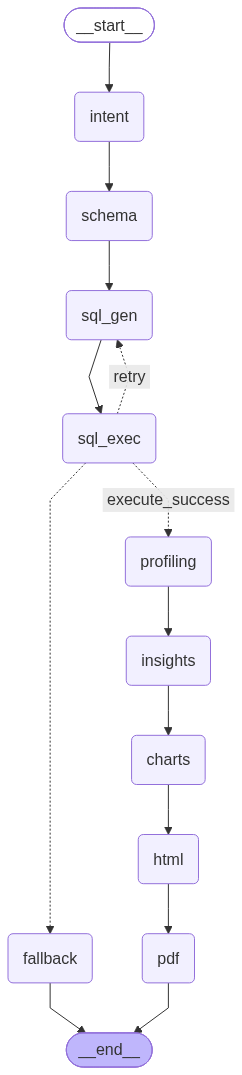

In [7]:
# Cell 5: Advanced State Routing Configuration Graph Mapping
def check_sql_validity_route(state: AgentState) -> str:
    # Handles Image Route Checks: "Is SQL Valid?" & Error Evaluation Loop Switch
    if state.get("error"):
        if state.get("retry_count", 0) >= 3:
            print("   -> [Route Decision] Loop broken: Max iterations hit. Triggering Fallback Node.")
            return "fallback"
        print("   -> [Route Decision] Loop exception found: routing back to correction editor...")
        return "retry"
    return "execute_success"

def fallback_response_node(state: AgentState) -> dict:
    print("-> [Fallback Node] Compiling emergency report configuration...")
    return {"error": "Critical execution boundary failure. Report generated via empty state constraints."}

# Build LangGraph Network Mapping Coordinates
workflow = StateGraph(AgentState)

# Append System Process Operators
workflow.add_node("intent", intent_understanding_node)
workflow.add_node("schema", schema_context_retrieval_node)
workflow.add_node("sql_gen", sql_generation_node)
workflow.add_node("sql_exec", sql_execution_node)
workflow.add_node("profiling", data_profiling_aggregation_node)
workflow.add_node("insights", analysis_insights_node)
workflow.add_node("charts", chart_generation_node)
workflow.add_node("html", html_report_generation_node)
workflow.add_node("pdf", pdf_compilation_node)
workflow.add_node("fallback", fallback_response_node)

# Connect Flow Nodes
workflow.add_edge(START, "intent")
workflow.add_edge("intent", "schema")
workflow.add_edge("schema", "sql_gen")
workflow.add_edge("sql_gen", "sql_exec")

# Conditional Routing Edge Implementation (SQL Validation & Safety Check Loop)
workflow.add_conditional_edges(
    "sql_exec",
    check_sql_validity_route,
    {
        "retry": "sql_gen",
        "fallback": "fallback",
        "execute_success": "profiling"
    }
)

workflow.add_edge("profiling", "insights")
workflow.add_edge("insights", "charts")
workflow.add_edge("charts", "html")
workflow.add_edge("html", "pdf")
workflow.add_edge("pdf", END)
workflow.add_edge("fallback", END)

app = workflow.compile()
app

In [9]:
# Cell 6: Execution Trigger Execution
if __name__ == "__main__":
    # initial_input = {
    #     "prompt": "Get all work orders grouped by number with planned and completed quantities matching production runs.",
    #     "retry_count": 0,
    #     "error": None
    # }
    initial_input = {
    "prompt": "Generate a production report showing all work orders with planned quantity, completed production quantity, rejected quantity, completion percentage, and machine-wise performance. Include production trends and identify underperforming work orders or machines.",
    "retry_count": 0,
    "error": None
}
    
    print("--- STARTING LANGGRAPH ENGINE OPERATION ---")
    for event in app.stream(initial_input):
        pass
    print("--- CONFIGURATION COMPLETED ---")


--- STARTING LANGGRAPH ENGINE OPERATION ---
-> [Node 1] parsing user request intent...
-> [Node 2] Fetching allowed relational schema metadata...
-> [Node 3] Generating read-only SQL string...
-> [Node 4] Executing validated query inside target data source...
   [Correction Loop Warning] SQL execution failed: Execution failed on sql 'An elegant and comprehensive production performance report can be generated using a single ANSI SQL query with SQLite-compliant window functions. This query calculates individual work order metrics, identifies underperforming orders, aggregates performance at the machine level, and flags underperforming machines.


SELECT 
    wo.WorkOrderId,
    wo.WorkOrderNumber,
    wo.Status AS WorkOrderStatus,
    m.MachineName,
    m.MachineCode,
    op.OperatorName,
    op.Department AS OperatorDepartment,
    sm.ShiftName,
    wo.PlannedQty AS PlannedQuantity,
    wo.CompletedQty AS CompletedQuantity,
    -- Estimating rejected/shortfall quantity
    CASE 
       

C:\Users\renuk\AppData\Local\Temp\ipykernel_18544\1119855867.py:49: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


-> [Node 9] Initiating ReportLab engine for advanced layout mapping...
-> Production PDF successfully written via pure python: c:\Users\renuk\OneDrive\Desktop\MANUFACTURING AGENTIC AI\Manufacturing-Agentic-Ai-iiiot\jupyter notebooks\reports\premium_report_0cce1b6e.pdf
--- CONFIGURATION COMPLETED ---
